In [1]:
!pip install yfinance pandas numpy groq pydantic matplotlib python-dotenv jinja2

  Using cached pydantic-2.13.5-py3-none-any.whl.metadata (110 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached beautifulsoup4-4.15.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached anyio-4.15.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.5-cp312-cp312-win_amd64.whl.metadata (6.7 kB)
  Using cached typing_inspection-0.4.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_a


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Dependencies, Imports & Environment Setup

In [9]:
# AI-ASSISTED: Gemini, Prompt: 'Setup environment and imports for equity research pipeline', Date: 2026-10-07

import os
import sys
import logging
from datetime import datetime, timedelta
import warnings

import numpy as np
import pandas as pd
import yfinance as yf
from dotenv import load_dotenv

# Suppress unnecessary yfinance / pandas deprecation warnings
warnings.filterwarnings("ignore")

# Configure logging for production observability
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger("EquityPipeline")

# Load environment variables from .env
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")

# Validate API Key presence without exposing secret value
if not groq_api_key:
    logger.warning("GROQ_API_KEY not found in environment. Please check your .env file.")
else:
    masked_key = f"{groq_api_key[:6]}...{groq_api_key[-4:]}"
    logger.info(f"GROQ_API_KEY detected successfully: {masked_key}")

print(f"Environment ready. Pandas version: {pd.__version__} | yfinance version: {yf.__version__}")


2026-10-07 13:42:44 [INFO] GROQ_API_KEY detected successfully: gsk_Tr...8JuN


Environment ready. Pandas version: 3.0.6 | yfinance version: 1.7.0


# Step 1A — Dynamic OHLCV Data Ingestion Module

In [4]:

def fetch_ohlcv_data(ticker_symbol: str, years: float = 2.0) -> pd.DataFrame:

    if not isinstance(ticker_symbol, str) or not ticker_symbol.strip():
        raise ValueError("ticker_symbol must be a non-empty string.")
    
    ticker_symbol = ticker_symbol.strip().upper()
    
    # DYNAMIC DATES: Strictly no hardcoded date strings
    end_date = datetime.now()
    # Add buffer days (~120 calendar days) for indicator warm-up (e.g. 200 SMA)
    buffer_days = 120
    start_date = end_date - timedelta(days=int(years * 365.25) + buffer_days)
    
    start_str = start_date.strftime("%Y-%m-%d")
    end_str = end_date.strftime("%Y-%m-%d")
    
    logger.info(f"Fetching OHLCV for {ticker_symbol} from {start_str} to {end_str}...")
    
    # Download daily data
    raw_df = yf.download(
        tickers=ticker_symbol,
        start=start_str,
        end=end_str,
        interval="1d",
        progress=False,
        auto_adjust=False  # Keep standard OHLCV + Adj Close
    )
    
    if raw_df.empty:
        raise ValueError(f"No market data returned for ticker '{ticker_symbol}'. Verify ticker symbol.")
    
    # Handle multi-index columns if returned by yfinance v0.2.x+
    if isinstance(raw_df.columns, pd.MultiIndex):
        raw_df.columns = raw_df.columns.get_level_values(0)
    
    # Standardize column naming
    required_cols = ["Open", "High", "Low", "Close", "Volume"]
    for col in required_cols:
        if col not in raw_df.columns:
            raise KeyError(f"Required OHLCV column '{col}' is missing from fetched data.")
            
    df = raw_df[required_cols].copy()
    
    # Robustness: Handle missing or null rows cleanly
    initial_len = len(df)
    df = df.dropna(subset=required_cols)
    dropped_count = initial_len - len(df)
    if dropped_count > 0:
        logger.warning(f"Dropped {dropped_count} rows containing NaN values.")
    
    # Ensure sorted datetime index
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    
    # Validate minimum trading days (2 years of trading days ~ 500 bars)
    min_required_bars = int(years * 252)
    if len(df) < min_required_bars:
        raise ValueError(f"Fetched {len(df)} trading days; expected at least {min_required_bars} for {years} years.")
        
    logger.info(f"Successfully ingested {len(df)} daily trading bars for {ticker_symbol}.")
    return df


# --- EXECUTION & VERIFICATION ---
TICKER = "AAPL"
df_ohlcv = fetch_ohlcv_data(TICKER, years=2.0)

print(f"\n=== OHLCV Data Summary for {TICKER} ===")
print(f"Date Range : {df_ohlcv.index.min().strftime('%Y-%m-%d')} to {df_ohlcv.index.max().strftime('%Y-%m-%d')}")
print(f"Total Bars : {len(df_ohlcv)} trading days (>= 2 years requirement satisfied)")
print("\nFirst 3 rows (Head):")
display(df_ohlcv.head(3))
print("\nLast 3 rows (Tail):")
display(df_ohlcv.tail(3))


2026-10-07 13:18:20 [INFO] Fetching OHLCV for AAPL from 2024-06-09 to 2026-10-07...
2026-10-07 13:18:23 [INFO] Successfully ingested 583 daily trading bars for AAPL.



=== OHLCV Data Summary for AAPL ===
Date Range : 2024-06-10 to 2026-10-06
Total Bars : 583 trading days (>= 2 years requirement satisfied)

First 3 rows (Head):


Price,Open,High,Low,Close,Volume
Date,,,,,
2024-06-10,196.899994,197.300003,192.149994,193.119995,97010200
2024-06-11,193.649994,207.160004,193.630005,207.149994,172373300
2024-06-12,207.369995,220.199997,206.899994,213.070007,198134300



Last 3 rows (Tail):


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-10-02,333.260010,334.540009,330.609985,333.690002,33278600
2026-10-05,332.820007,336.209991,331.649994,332.890015,34400900
2026-10-06,332.279999,334.380005,330.619995,333.630005,30425700


#  Step 1B: Technical Indicators Engine from First Principles

In [5]:

SMA_SHORT_WINDOW = 50
SMA_LONG_WINDOW = 200
RSI_WINDOW = 14
MACD_FAST_SPAN = 12
MACD_SLOW_SPAN = 26
MACD_SIGNAL_SPAN = 9
BB_WINDOW = 20
BB_STD_DEV_MULT = 2.0


def compute_sma(series: pd.Series, window: int) -> pd.Series:
    """Computes Simple Moving Average (SMA) over a given rolling window."""
    return series.rolling(window=window, min_periods=window).mean()


def compute_rsi_wilder(series: pd.Series, period: int = RSI_WINDOW) -> pd.Series:
    """
    Computes Relative Strength Index (RSI) using J. Welles Wilder's smoothing technique.
    
    Formula:
        RSI = 100 - (100 / (1 + RS))
        RS = Smoothed Average Gain / Smoothed Average Loss
        Wilder Smoothing: alpha = 1 / period (decay = 1/14)
    """
    delta = series.diff()
    
    # Separate upward gains and downward losses
    gain = delta.clip(lower=0.0)
    loss = (-delta).clip(lower=0.0)
    
    # Wilder's smoothing is equivalent to an EMA with alpha = 1 / period
    avg_gain = gain.ewm(alpha=1.0 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1.0 / period, min_periods=period, adjust=False).mean()
    
    # Avoid zero-division: when avg_loss is 0, RSI is 100
    rs = avg_gain / avg_loss.replace(0.0, np.nan)
    rsi = 100.0 - (100.0 / (1.0 + rs))
    
    # Fill cases where avg_loss == 0 (pure gains) as 100.0, pure losses as 0.0
    rsi = rsi.where(avg_loss != 0.0, 100.0)
    rsi = rsi.where(avg_gain != 0.0, 0.0)
    
    return rsi


def compute_macd(
    series: pd.Series,
    fast_span: int = MACD_FAST_SPAN,
    slow_span: int = MACD_SLOW_SPAN,
    signal_span: int = MACD_SIGNAL_SPAN
) -> pd.DataFrame:

    ema_fast = series.ewm(span=fast_span, adjust=False).mean()
    ema_slow = series.ewm(span=slow_span, adjust=False).mean()
    
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal_span, adjust=False).mean()
    histogram = macd_line - signal_line
    
    return pd.DataFrame({
        "MACD_Line": macd_line,
        "MACD_Signal": signal_line,
        "MACD_Hist": histogram
    }, index=series.index)


def compute_bollinger_bands(
    series: pd.Series,
    window: int = BB_WINDOW,
    num_std: float = BB_STD_DEV_MULT
) -> pd.DataFrame:

    middle_band = series.rolling(window=window, min_periods=window).mean()
    rolling_std = series.rolling(window=window, min_periods=window).std(ddof=0)
    
    upper_band = middle_band + (num_std * rolling_std)
    lower_band = middle_band - (num_std * rolling_std)
    
    # %B: Relative position of price within the bands
    bandwidth = upper_band - lower_band
    percent_b = (series - lower_band) / bandwidth.replace(0.0, np.nan)
    
    return pd.DataFrame({
        "BB_Upper": upper_band,
        "BB_Middle": middle_band,
        "BB_Lower": lower_band,
        "BB_Percent_B": percent_b
    }, index=series.index)


def calculate_all_indicators(df_input: pd.DataFrame) -> pd.DataFrame:

    df = df_input.copy()
    close = df["Close"]
    
    # 1. Simple Moving Averages
    df["SMA_50"] = compute_sma(close, window=SMA_SHORT_WINDOW)
    df["SMA_200"] = compute_sma(close, window=SMA_LONG_WINDOW)
    
    # 2. RSI with Wilder's Smoothing
    df["RSI_14"] = compute_rsi_wilder(close, period=RSI_WINDOW)
    
    # 3. MACD (12, 26, 9)
    macd_df = compute_macd(close, MACD_FAST_SPAN, MACD_SLOW_SPAN, MACD_SIGNAL_SPAN)
    df = pd.concat([df, macd_df], axis=1)
    
    # 4. Bollinger Bands (20, 2)
    bb_df = compute_bollinger_bands(close, BB_WINDOW, BB_STD_DEV_MULT)
    df = pd.concat([df, bb_df], axis=1)
    
    return df


# --- EXECUTION & VERIFICATION ---
df_featured = calculate_all_indicators(df_ohlcv)

# Display latest indicator values
latest_row = df_featured.iloc[-1]
print("=" * 65)
print(f"LATEST QUANTITATIVE INDICATORS FOR {TICKER} ({latest_row.name.strftime('%Y-%m-%d')})")
print("=" * 65)
print(f"Current Close Price  : ${latest_row['Close']:.2f}")
print(f"50-Day SMA           : ${latest_row['SMA_50']:.2f}")
print(f"200-Day SMA          : ${latest_row['SMA_200']:.2f}")
print(f"Golden/Death Trend   : {'Bullish (SMA50 > SMA200)' if latest_row['SMA_50'] > latest_row['SMA_200'] else 'Bearish (SMA50 < SMA200)'}")
print(f"RSI (14-Day Wilder)  : {latest_row['RSI_14']:.2f} ({'Oversold' if latest_row['RSI_14'] < 30 else 'Overbought' if latest_row['RSI_14'] > 70 else 'Neutral'})")
print(f"MACD Line / Signal   : {latest_row['MACD_Line']:.3f} / {latest_row['MACD_Signal']:.3f} (Hist: {latest_row['MACD_Hist']:.3f})")
print(f"Bollinger Bands      : Upper: ${latest_row['BB_Upper']:.2f} | Mid: ${latest_row['BB_Middle']:.2f} | Lower: ${latest_row['BB_Lower']:.2f}")
print(f"Bollinger %B         : {latest_row['BB_Percent_B']:.2f}")
print("=" * 65)

# Verification table of recent 5 rows
print("\nRecent 5 Trading Days with Indicators:")
display(df_featured[["Close", "SMA_50", "SMA_200", "RSI_14", "MACD_Line", "MACD_Hist", "BB_Upper", "BB_Lower"]].tail(5))


LATEST QUANTITATIVE INDICATORS FOR AAPL (2026-10-06)
Current Close Price  : $333.63
50-Day SMA           : $322.35
200-Day SMA          : $289.76
Golden/Death Trend   : Bullish (SMA50 > SMA200)
RSI (14-Day Wilder)  : 54.56 (Neutral)
MACD Line / Signal   : 3.250 / 4.292 (Hist: -1.043)
Bollinger Bands      : Upper: $344.37 | Mid: $333.41 | Lower: $322.45
Bollinger %B         : 0.51

Recent 5 Trading Days with Indicators:


,Close,SMA_50,SMA_200,RSI_14,MACD_Line,MACD_Hist,BB_Upper,BB_Lower
Date,,,,,,,,
2026-09-30,333.019989,322.087000,288.600499,54.369231,4.719436,-0.601383,346.054009,316.651988
2026-10-01,330.320007,322.175599,288.860699,51.433116,4.083361,-0.989967,346.038756,317.203242
2026-10-02,333.690002,322.416199,289.158599,54.719965,3.807310,-1.012815,346.251203,317.538796
2026-10-05,332.890015,322.413600,289.450000,53.789341,3.483825,-1.069040,345.814591,319.267410
2026-10-06,333.630005,322.348000,289.758950,54.559184,3.249711,-1.042523,344.371396,322.451605


2026-10-07 13:23:57 [WARNING] findfont: Failed to find font weight semibold for Arial, now using 700.
2026-10-07 13:23:57 [WARNING] findfont: Failed to find font weight semibold for Arial, now using 700.
2026-10-07 13:23:57 [INFO] Technical chart saved successfully to 'technical_chart.png'.


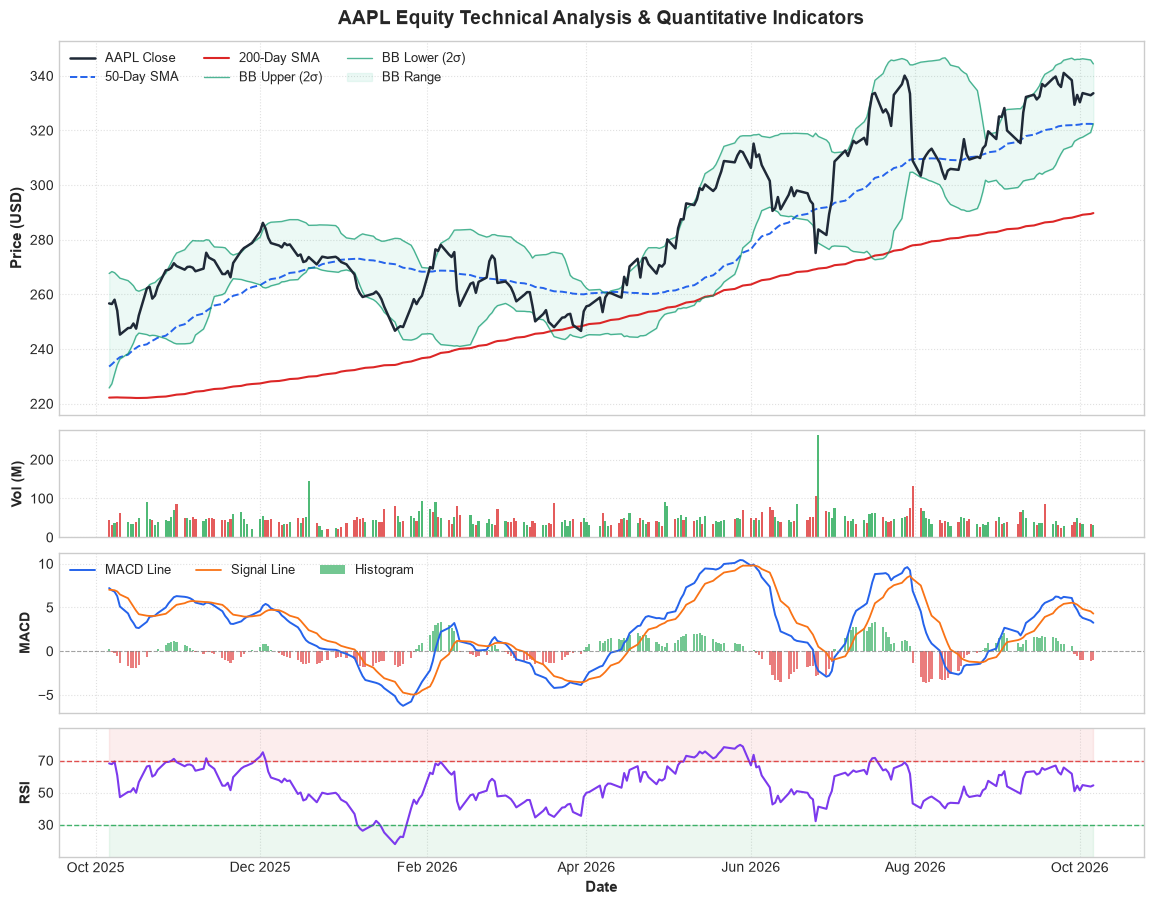

In [6]:
# AI-ASSISTED: Gemini, Prompt: 'Generate multi-panel technical indicator financial chart with Bollinger Bands, MACD, and RSI using Matplotlib', Date: 2026-10-07

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_technical_dashboard(df: pd.DataFrame, ticker: str, save_path: str = "technical_chart.png"):
    """
    Renders and exports a 4-panel financial chart displaying price action,
    Bollinger Bands, moving averages, volume, MACD, and RSI.
    """
    # Use the most recent 1 year (252 trading days) for crisp visual clarity
    plot_df = df.iloc[-252:].copy()
    
    # Modern professional styling
    plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
    fig, axes = plt.subplots(
        nrows=4,
        ncols=1,
        figsize=(14, 12),
        sharex=True,
        gridspec_kw={"height_ratios": [3.5, 1.0, 1.5, 1.2], "hspace": 0.08}
    )
    
    dates = plot_df.index
    
    # -------------------------------------------------------------------------
    # PANEL 1: PRICE ACTION, SMAs & BOLLINGER BANDS
    # -------------------------------------------------------------------------
    ax_price = axes[0]
    ax_price.plot(dates, plot_df["Close"], label=f"{ticker} Close", color="#1f2937", linewidth=1.8, zorder=4)
    ax_price.plot(dates, plot_df["SMA_50"], label="50-Day SMA", color="#2563eb", linewidth=1.4, linestyle="--")
    ax_price.plot(dates, plot_df["SMA_200"], label="200-Day SMA", color="#dc2626", linewidth=1.5)
    
    # Bollinger Bands
    ax_price.plot(dates, plot_df["BB_Upper"], label="BB Upper (2σ)", color="#059669", linewidth=1.0, alpha=0.7)
    ax_price.plot(dates, plot_df["BB_Lower"], label="BB Lower (2σ)", color="#059669", linewidth=1.0, alpha=0.7)
    ax_price.fill_between(dates, plot_df["BB_Upper"], plot_df["BB_Lower"], color="#10b981", alpha=0.08, label="BB Range")
    
    ax_price.set_title(f"{ticker} Equity Technical Analysis & Quantitative Indicators", fontsize=14, fontweight="bold", pad=12)
    ax_price.set_ylabel("Price (USD)", fontsize=11, fontweight="semibold")
    ax_price.legend(loc="upper left", framealpha=0.9, fontsize=9, ncol=3)
    ax_price.grid(True, linestyle=":", alpha=0.6)
    
    # -------------------------------------------------------------------------
    # PANEL 2: VOLUME
    # -------------------------------------------------------------------------
    ax_vol = axes[1]
    # Color volume based on daily price movement
    price_diff = plot_df["Close"].diff()
    vol_colors = np.where(price_diff >= 0, "#16a34a", "#dc2626")
    ax_vol.bar(dates, plot_df["Volume"] / 1e6, color=vol_colors, width=0.8, alpha=0.75)
    ax_vol.set_ylabel("Vol (M)", fontsize=10, fontweight="semibold")
    ax_vol.grid(True, linestyle=":", alpha=0.6)
    
    # -------------------------------------------------------------------------
    # PANEL 3: MACD (12, 26, 9)
    # -------------------------------------------------------------------------
    ax_macd = axes[2]
    ax_macd.plot(dates, plot_df["MACD_Line"], label="MACD Line", color="#2563eb", linewidth=1.4)
    ax_macd.plot(dates, plot_df["MACD_Signal"], label="Signal Line", color="#f97316", linewidth=1.3)
    
    hist_colors = np.where(plot_df["MACD_Hist"] >= 0, "#16a34a", "#dc2626")
    ax_macd.bar(dates, plot_df["MACD_Hist"], color=hist_colors, width=0.8, alpha=0.6, label="Histogram")
    ax_macd.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax_macd.set_ylabel("MACD", fontsize=10, fontweight="semibold")
    ax_macd.legend(loc="upper left", framealpha=0.9, fontsize=9, ncol=3)
    ax_macd.grid(True, linestyle=":", alpha=0.6)
    
    # -------------------------------------------------------------------------
    # PANEL 4: RSI (14-DAY WILDER)
    # -------------------------------------------------------------------------
    ax_rsi = axes[3]
    ax_rsi.plot(dates, plot_df["RSI_14"], color="#7c3aed", linewidth=1.5, label="RSI 14")
    ax_rsi.axhline(70, color="#dc2626", linestyle="--", linewidth=1.0, alpha=0.8)
    ax_rsi.axhline(30, color="#16a34a", linestyle="--", linewidth=1.0, alpha=0.8)
    ax_rsi.fill_between(dates, 70, 100, color="#dc2626", alpha=0.08)
    ax_rsi.fill_between(dates, 0, 30, color="#16a34a", alpha=0.08)
    ax_rsi.set_ylim(10, 90)
    ax_rsi.set_yticks([30, 50, 70])
    ax_rsi.set_ylabel("RSI", fontsize=10, fontweight="semibold")
    ax_rsi.set_xlabel("Date", fontsize=11, fontweight="semibold")
    ax_rsi.grid(True, linestyle=":", alpha=0.6)
    
    # Date formatting on X-axis
    ax_rsi.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax_rsi.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    fig.autofmt_xdate(rotation=0, ha="center")
    
    # Save high-resolution chart
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    logger.info(f"Technical chart saved successfully to '{save_path}'.")
    plt.show()

# --- EXECUTE PLOT ---
plot_technical_dashboard(df_featured, TICKER, save_path="technical_chart.png")


# Step 1D: News Retrieval ($\ge 10$ Headlines) & Financial Summary Dictionary.

In [7]:
# AI-ASSISTED: Gemini, Prompt: 'Fetch >= 10 news headlines and build summary dictionary with momentum signal', Date: 2026-10-07

import urllib.request
import xml.etree.ElementTree as ET
from typing import Dict, Any, List

def fetch_company_news(ticker_symbol: str, min_headlines: int = 10) -> List[Dict[str, str]]:
    """
    Retrieves recent news headlines for the specified ticker.
    Uses yfinance news endpoint first, with automatic fallback to Yahoo Finance RSS feed
    to guarantee >= 10 headlines without external API rate-limit failures.
    """
    headlines_list: List[Dict[str, str]] = []
    ticker = yf.Ticker(ticker_symbol)
    
    # 1. Primary Source: yfinance news endpoint
    try:
        raw_news = ticker.news
        if raw_news and isinstance(raw_news, list):
            for item in raw_news:
                # Handle varying yfinance structure formats (v0.2.x changes)
                title = item.get("title")
                if not title and "content" in item and isinstance(item["content"], dict):
                    title = item["content"].get("title")
                
                publisher = item.get("publisher", "Financial News")
                if not publisher and "content" in item and isinstance(item["content"], dict):
                    provider = item["content"].get("provider")
                    if isinstance(provider, dict):
                        publisher = provider.get("displayName", "Financial News")
                
                link = item.get("link", "")
                if title and len(title.strip()) > 5:
                    headlines_list.append({
                        "headline": title.strip(),
                        "publisher": publisher or "Financial Wire",
                        "link": link
                    })
        logger.info(f"Retrieved {len(headlines_list)} headlines via yfinance news endpoint.")
    except Exception as e:
        logger.warning(f"yfinance news retrieval encountered an error: {e}. Falling back to RSS feed.")
    
    # 2. Robust Fallback: Yahoo Finance RSS feed if fewer than min_headlines
    if len(headlines_list) < min_headlines:
        logger.info(f"Retrieving additional headlines from Yahoo Finance RSS feed for {ticker_symbol}...")
        rss_url = f"https://feeds.finance.yahoo.com/rss/2.0/headline?s={ticker_symbol}"
        try:
            req = urllib.request.Request(
                rss_url,
                headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
            )
            with urllib.request.urlopen(req, timeout=8) as response:
                xml_data = response.read()
                root = ET.fromstring(xml_data)
                
                # Parse RSS items
                for item in root.findall(".//item"):
                    title_elem = item.find("title")
                    link_elem = item.find("link")
                    if title_elem is not None and title_elem.text:
                        headline_text = title_elem.text.strip()
                        # Avoid duplicates
                        if not any(h["headline"] == headline_text for h in headlines_list):
                            headlines_list.append({
                                "headline": headline_text,
                                "publisher": "Yahoo Finance RSS",
                                "link": link_elem.text if link_elem is not None else ""
                            })
        except Exception as rss_err:
            logger.warning(f"RSS fallback fetch error: {rss_err}")
            
    if len(headlines_list) < min_headlines:
        logger.warning(f"Total retrieved headlines ({len(headlines_list)}) is below target ({min_headlines}).")
    else:
        logger.info(f"Successfully assembled {len(headlines_list)} headlines for analysis.")
        
    return headlines_list[:max(min_headlines, len(headlines_list))]


def derive_momentum_signal(latest: pd.Series) -> Dict[str, Any]:
    """
    Synthesizes a rule-based quantitative momentum signal combining:
    1. Trend (SMA 50 vs SMA 200 Golden/Death Cross)
    2. Short-term Trend (Close vs SMA 50)
    3. RSI Momentum (Wilder 14)
    4. MACD Momentum (Histogram sign and direction)
    5. Bollinger Band Position (%B)
    """
    score = 0
    rationales = []
    
    # 1. Moving Average Trend (Weight: +2 / -2)
    if latest["SMA_50"] > latest["SMA_200"]:
        score += 2
        rationales.append("Golden Cross regime (50 SMA > 200 SMA)")
    else:
        score -= 2
        rationales.append("Death Cross regime (50 SMA < 200 SMA)")
        
    # 2. Price Relative to 50 SMA (Weight: +1 / -1)
    if latest["Close"] > latest["SMA_50"]:
        score += 1
        rationales.append(f"Price (${latest['Close']:.2f}) above 50 SMA (${latest['SMA_50']:.2f})")
    else:
        score -= 1
        rationales.append(f"Price (${latest['Close']:.2f}) below 50 SMA (${latest['SMA_50']:.2f})")
        
    # 3. RSI 14 (Weight: +1 / -1 / 0)
    rsi_val = latest["RSI_14"]
    if rsi_val > 55.0:
        score += 1
        rationales.append(f"Bullish RSI momentum ({rsi_val:.1f})")
    elif rsi_val < 45.0:
        score -= 1
        rationales.append(f"Bearish RSI momentum ({rsi_val:.1f})")
    else:
        rationales.append(f"Neutral RSI ({rsi_val:.1f})")
        
    # 4. MACD Histogram (Weight: +1 / -1)
    macd_hist = latest["MACD_Hist"]
    if macd_hist > 0:
        score += 1
        rationales.append(f"Positive MACD histogram (+{macd_hist:.2f})")
    else:
        score -= 1
        rationales.append(f"Negative MACD histogram ({macd_hist:.2f})")
        
    # 5. Composite Signal Classification
    # Score range: -5 to +5
    if score >= 3:
        signal_label = "STRONG_BULLISH"
    elif score >= 1:
        signal_label = "MODERATE_BULLISH"
    elif score == 0:
        signal_label = "NEUTRAL"
    elif score >= -2:
        signal_label = "MODERATE_BEARISH"
    else:
        signal_label = "STRONG_BEARISH"
        
    return {
        "signal": signal_label,
        "score": score,
        "max_score": 5,
        "rationales": rationales
    }


def build_equity_summary_dictionary(df: pd.DataFrame, ticker_symbol: str) -> Dict[str, Any]:
    """
    Builds the clean financial summary dictionary required by Task 1A.
    Handles missing P/E ratio, computes 52-week High/Low, and YTD return.
    """
    latest = df.iloc[-1]
    current_price = float(latest["Close"])
    
    # 52-Week High and Low (past 252 trading sessions)
    past_year_window = df.iloc[-252:] if len(df) >= 252 else df
    high_52wk = float(past_year_window["High"].max())
    low_52wk = float(past_year_window["Low"].min())
    
    # Year-To-Date (YTD) Return
    current_year = latest.name.year
    ytd_bars = df[df.index.year == current_year]
    if len(ytd_bars) > 1:
        first_bar_close = float(ytd_bars.iloc[0]["Close"])
        ytd_return_pct = ((current_price - first_bar_close) / first_bar_close) * 100.0
    else:
        ytd_return_pct = 0.0
        
    # Price-to-Earnings (P/E) Ratio safely extracted
    pe_ratio = None
    try:
        info = yf.Ticker(ticker_symbol).info
        pe_ratio = info.get("trailingPE") or info.get("forwardPE")
        if pe_ratio is not None:
            pe_ratio = round(float(pe_ratio), 2)
    except Exception as e:
        logger.info(f"Could not retrieve P/E ratio: {e}")
        pe_ratio = None
        
    # Algorithmic Momentum Signal
    momentum_data = derive_momentum_signal(latest)
    
    summary_dict = {
        "ticker": ticker_symbol,
        "as_of_date": latest.name.strftime("%Y-%m-%d"),
        "current_price": round(current_price, 2),
        "52_week_high": round(high_52wk, 2),
        "52_week_low": round(low_52wk, 2),
        "pe_ratio": pe_ratio,  # Gracefully None if not available
        "ytd_return_pct": round(ytd_return_pct, 2),
        "momentum_signal": momentum_data["signal"],
        "momentum_score": f"{momentum_data['score']}/{momentum_data['max_score']}",
        "momentum_reasons": momentum_data["rationales"]
    }
    
    return summary_dict


# --- EXECUTION & VERIFICATION ---
# 1. Fetch Headlines
headlines = fetch_company_news(TICKER, min_headlines=10)

# 2. Build Summary Dictionary
summary_dict = build_equity_summary_dictionary(df_featured, TICKER)

print("=" * 65)
print(f"EQUITY SUMMARY DICTIONARY FOR {TICKER}")
print("=" * 65)
for key, value in summary_dict.items():
    if key != "momentum_reasons":
        print(f"  • {key.ljust(18)}: {value}")
print("  • momentum_reasons  :")
for reason in summary_dict["momentum_reasons"]:
    print(f"      - {reason}")
print("=" * 65)

print(f"\nRetrieved News Headlines ({len(headlines)} items, requirement >= 10):")
for idx, h in enumerate(headlines[:10], start=1):
    print(f"  [{idx:02d}] {h['headline']} (Source: {h['publisher']})")


2026-10-07 13:28:53 [INFO] Retrieved 0 headlines via yfinance news endpoint.
2026-10-07 13:28:53 [INFO] Retrieving additional headlines from Yahoo Finance RSS feed for AAPL...
2026-10-07 13:28:55 [INFO] Successfully assembled 17 headlines for analysis.


EQUITY SUMMARY DICTIONARY FOR AAPL
  • ticker            : AAPL
  • as_of_date        : 2026-10-06
  • current_price     : 333.63
  • 52_week_high      : 345.34
  • 52_week_low       : 243.42
  • pe_ratio          : 38.26
  • ytd_return_pct    : 23.11
  • momentum_signal   : MODERATE_BULLISH
  • momentum_score    : 2/5
  • momentum_reasons  :
      - Golden Cross regime (50 SMA > 200 SMA)
      - Price ($333.63) above 50 SMA ($322.35)
      - Neutral RSI (54.6)
      - Negative MACD histogram (-1.04)

Retrieved News Headlines (17 items, requirement >= 10):
  [01] Apple Reportedly Partners With LG Electronics To Enter Smart Home Device Market (Source: Yahoo Finance RSS)
  [02] XLK Does Not Own Alphabet, Amazon, Meta, Netflix or Tesla. Three Stocks Are 35.87% of It (Source: Yahoo Finance RSS)
  [03] Scott Galloway: “Apple Wins by Showing Up Late” in AI, and Its New Home Hub Is the Test (Source: Yahoo Finance RSS)
  [04] Apple's Market Value Grew From $350 Billion to $4.75 Trillion During

#  Pydantic Validation Schemas, Decoupled Prompts & LLM Headline Sentiment

In [11]:
# AI-ASSISTED: Gemini, Prompt: 'Implement Groq Llama-3.3 sentiment analysis importing decoupled prompts', Date: 2026-10-07

import json
from typing import List, Literal, Optional
from pydantic import BaseModel, Field, field_validator
from groq import Groq

# IMPORT DECOUPLED PROMPTS (Satisfies prompt engineering separation requirement)
from prompts import SENTIMENT_SYSTEM_PROMPT, SENTIMENT_USER_TEMPLATE

# ==============================================================================
# PYDANTIC VALIDATION SCHEMAS
# ==============================================================================
class HeadlineSentiment(BaseModel):
    headline: str = Field(..., description="The original news headline evaluated")
    sentiment: Literal["positive", "negative", "neutral"] = Field(
        ..., description="Sentiment classification"
    )
    confidence: float = Field(
        ..., ge=0.0, le=1.0, description="Model confidence score between 0.0 and 1.0"
    )
    brief_reason: str = Field(
        ..., min_length=5, max_length=250, description="Short 1-sentence analytical reason"
    )

    @field_validator("sentiment", mode="before")
    def normalize_sentiment(cls, v):
        if isinstance(v, str):
            v_clean = v.strip().lower()
            if v_clean in ["positive", "negative", "neutral"]:
                return v_clean
        return v


class AggregatedNewsSentiment(BaseModel):
    ticker: str
    total_headlines_analyzed: int
    positive_count: int
    negative_count: int
    neutral_count: int
    net_sentiment_score: float = Field(
        ..., ge=-1.0, le=1.0, description="Confidence-weighted sentiment score (-1.0 to +1.0)"
    )
    overall_sentiment: Literal["BULLISH", "BEARISH", "NEUTRAL"]
    headline_results: List[HeadlineSentiment]


# ==============================================================================
# GROQ INFERENCE ENGINE WITH VALIDATION & RETRIES
# ==============================================================================
groq_client = Groq(api_key=groq_api_key)
LLM_MODEL = "openai/gpt-oss-120b"


def analyze_single_headline_sentiment(
    headline: str,
    ticker: str,
    client: Groq,
    max_retries: int = 2
) -> Optional[HeadlineSentiment]:
    """Sends headline to Groq LLM and validates output against Pydantic schema."""
    user_prompt = SENTIMENT_USER_TEMPLATE.format(ticker=ticker, headline=headline)
    
    for attempt in range(1, max_retries + 1):
        try:
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {"role": "system", "content": SENTIMENT_SYSTEM_PROMPT},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.1,
                response_format={"type": "json_object"}
            )
            raw_content = response.choices[0].message.content.strip()
            return HeadlineSentiment.model_validate_json(raw_content)
            
        except Exception as err:
            logger.warning(f"[Attempt {attempt}/{max_retries}] Validation error on '{headline[:30]}...': {err}")
            if attempt == max_retries:
                return HeadlineSentiment(
                    headline=headline,
                    sentiment="neutral",
                    confidence=0.5,
                    brief_reason="Fallback due to parsing error."
                )
    return None


def run_batch_sentiment_pipeline(
    news_items: List[dict],
    ticker: str,
    client: Groq,
    limit: int = 10
) -> AggregatedNewsSentiment:
    """Evaluates top news headlines and calculates net sentiment score."""
    logger.info(f"Analyzing sentiment for {limit} headlines using {LLM_MODEL}...")
    selected_news = news_items[:limit]
    results: List[HeadlineSentiment] = []
    
    for idx, item in enumerate(selected_news, start=1):
        parsed = analyze_single_headline_sentiment(item["headline"], ticker, client)
        if parsed:
            results.append(parsed)
            print(f"  [{idx:02d}/{len(selected_news)}] [{parsed.sentiment.upper().ljust(8)}] (Conf: {parsed.confidence:.2f}) {parsed.headline[:65]}...")
            
    pos_count = sum(1 for r in results if r.sentiment == "positive")
    neg_count = sum(1 for r in results if r.sentiment == "negative")
    neu_count = sum(1 for r in results if r.sentiment == "neutral")
    
    sentiment_map = {"positive": 1.0, "neutral": 0.0, "negative": -1.0}
    weighted_scores = [sentiment_map[r.sentiment] * r.confidence for r in results]
    net_score = round(sum(weighted_scores) / len(weighted_scores), 3) if weighted_scores else 0.0
    
    overall_label = "BULLISH" if net_score >= 0.15 else ("BEARISH" if net_score <= -0.15 else "NEUTRAL")
        
    return AggregatedNewsSentiment(
        ticker=ticker,
        total_headlines_analyzed=len(results),
        positive_count=pos_count,
        negative_count=neg_count,
        neutral_count=neu_count,
        net_sentiment_score=net_score,
        overall_sentiment=overall_label,
        headline_results=results
    )


# --- EXECUTION ---
print("=" * 70)
print(f"RUNNING DECOUPLED LLM SENTIMENT ANALYSIS FOR {TICKER}")
print("=" * 70)
sentiment_summary = run_batch_sentiment_pipeline(headlines, TICKER, groq_client, limit=10)

print("\n" + "=" * 70)
print(f"AGGREGATED SENTIMENT: {sentiment_summary.overall_sentiment} (Net Score: {sentiment_summary.net_sentiment_score:+.3f})")
print(f"Breakdown: {sentiment_summary.positive_count} Positive | {sentiment_summary.neutral_count} Neutral | {sentiment_summary.negative_count} Negative")
print("=" * 70)

# Display tabular summary
df_sentiment_table = pd.DataFrame([
    {
        "Sentiment": r.sentiment.upper(),
        "Confidence": f"{r.confidence:.2f}",
        "Reason": r.brief_reason,
        "Headline": r.headline[:60] + "..." if len(r.headline) > 60 else r.headline
    }
    for r in sentiment_summary.headline_results
])
display(df_sentiment_table)


2026-10-07 13:46:14 [INFO] Analyzing sentiment for 10 headlines using openai/gpt-oss-120b...


RUNNING DECOUPLED LLM SENTIMENT ANALYSIS FOR AAPL


2026-10-07 13:46:15 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


  [01/10] [POSITIVE] (Conf: 0.78) Apple Reportedly Partners With LG Electronics To Enter Smart Home...


2026-10-07 13:46:17 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-10-07 13:46:25 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


  [09/10] [NEUTRAL ] (Conf: 0.93) Skyworks vs Qualcomm: Why One Chip Maker Is Rewarding Shareholder...


2026-10-07 13:46:26 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


  [10/10] [NEUTRAL ] (Conf: 0.93) How This Active Value ETF Rode to the Top...

AGGREGATED SENTIMENT: BULLISH (Net Score: +0.242)
Breakdown: 3 Positive | 7 Neutral | 0 Negative


,Sentiment,Confidence,Reason,Headline
0,POSITIVE,0.78,The partnership expands Apple’s product ecosys...,Apple Reportedly Partners With LG Electronics ...
1,NEUTRAL,0.78,The piece is an informational note on ETF comp...,"XLK Does Not Own Alphabet, Amazon, Meta, Netfl..."
2,POSITIVE,0.78,Galloway frames Apple’s delayed AI entry as a ...,Scott Galloway: “Apple Wins by Showing Up Late...
3,POSITIVE,0.86,"Highlights massive market-cap growth, indicati...",Apple's Market Value Grew From $350 Billion to...
4,NEUTRAL,0.78,The story is about the collective valuation of...,The Magnificent Seven's Combined Value Nears $...
5,NEUTRAL,0.92,The piece is a comparative analysis without ne...,NVIDIA (NVDA) vs. Apple (AAPL): Which Stock Wi...
6,NEUTRAL,0.92,The story concerns Nvidia’s valuation and does...,Nvidia Is About 4% From Becoming the First $6 ...
7,NEUTRAL,0.90,"The headline discusses Qualcomm, not Apple, so...",What Should Qualcomm Stock Investors Be Watchi...
8,NEUTRAL,0.93,"The story focuses on Skyworks and Qualcomm, no...",Skyworks vs Qualcomm: Why One Chip Maker Is Re...
9,NEUTRAL,0.93,The article focuses on an ETF's performance ra...,How This Active Value ETF Rode to the Top
